In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('..')

from model import *
from utils import *
from dataset import *
from PerturbVAE.trainer import *

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
data = sc.read_h5ad('./data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [5]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

In [6]:
module_df = pd.read_csv('./results/modules.csv')
module_df

,module,type,gene
0,0,TF,CEBPD
1,0,TF,ETV6
2,0,TF,NFKB1
3,0,TF,RELB
4,0,target,ABI3BP
...,...,...,...
3467,11,target,ZNF800
3468,11,target,ZNF804A
3469,11,target,ZNF827
3470,11,target,ZNFX1


In [7]:
# Collapse gene to unique indices
collapsed_df = module_df.groupby('gene').agg({
    'module': lambda x: ','.join(map(str, sorted(x))),
}).reset_index()


# Set the gene column as the index
collapsed_df.set_index('gene', inplace=True)

# Find the intersection of genes between data.var and collapsed_df
common_genes = data.var.index.intersection(collapsed_df.index)

# Subset data.var by the intersection of genes
data = data[: , common_genes].copy()

# # Add the module and type columns to data.var
data.var['module'] = collapsed_df.loc[common_genes, 'module']

In [8]:
dataset = PerturbMatchingDataset(data)

In [9]:
# sampler = MultiClassBatchSampler(
#     labels                = dataset.P_indices,
#     n_classes_per_batch   = 10,            # e.g. 4 classes per batch
#     shuffle_within_class  = True,         # optional
#     drop_last             = False          # drop incomplete last group
# )
# dataloader = DataLoader(dataset,
#                     batch_sampler=sampler)

dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=0)


In [10]:
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [11]:
input_dim = data.shape[-1] 
perturb_dim = len(data.obs['top_sg'].unique()) - 1  # Exclude the 'NA' control sgRNA
latent_dim = module_df['module'].max()+1

In [12]:
pyro.clear_param_store()

vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=data.var['module'].values,
                 center_coeff_init=1, use_gene_modules=True)
vae = vae.to(vae.device)

trainer = VAETrainer(
    vae,
    dataloader,
    lr=1e-3,
    num_epochs=300,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=1.0,
    tau_end=0.1,
    tau_anneal_steps=10000,
    #tau_anneal_steps=20000,  
    gate_start=50,
)

vae = trainer.fit()

Training VAE on cuda …


Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 296:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 297:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 298:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 299:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 300:   0%|          | 0/5 [00:00<?, ?it/s]

In [13]:
import pyro.poutine as poutine
model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))            

X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
X_ntc = []
for i in C:
    rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
    X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
X_ntc = torch.stack(X_ntc, dim=0)
                    
trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

z  = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

# --- map indices -> readable labels for obs ---
id2pert = {i: p for p, i in dataset.perturbation_dict.items()}
id2cond = {i: c for c, i in dataset.condition_dict.items()}
perturb_names = [id2pert[int(i)] for i in P.tolist()]
cond_names    = [id2cond[int(i)] for i in C.tolist()]

# --- build AnnData objects ---
# Perturbed rows
z_data = sc.AnnData(
    X=z.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": perturb_names, "treatment": cond_names})
)
z_data.obsm["z"] = z.detach().cpu().numpy()

# Matched control rows (NTC)
z0_data = sc.AnnData(
    X=z0.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": ["NTC"] * len(cond_names), "treatment": cond_names})
)

cpu


/opt/conda/envs/perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/conda/envs/perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
cls_logits = trace_model.nodes["cls_logits"]["value"]
val_correct = (cls_logits.argmax(dim=-1) == P).sum().item()
val_n = P.size(0)
acc = val_correct / val_n
print(f"Validation accuracy: {acc:.4f}")

Validation accuracy: 0.9700


In [15]:
# z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X_p.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


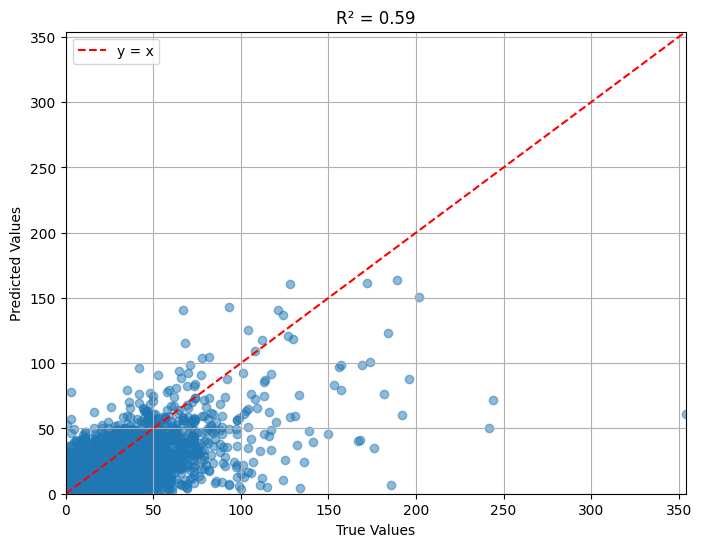

In [16]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(X_p.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, X_p.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = X_p[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


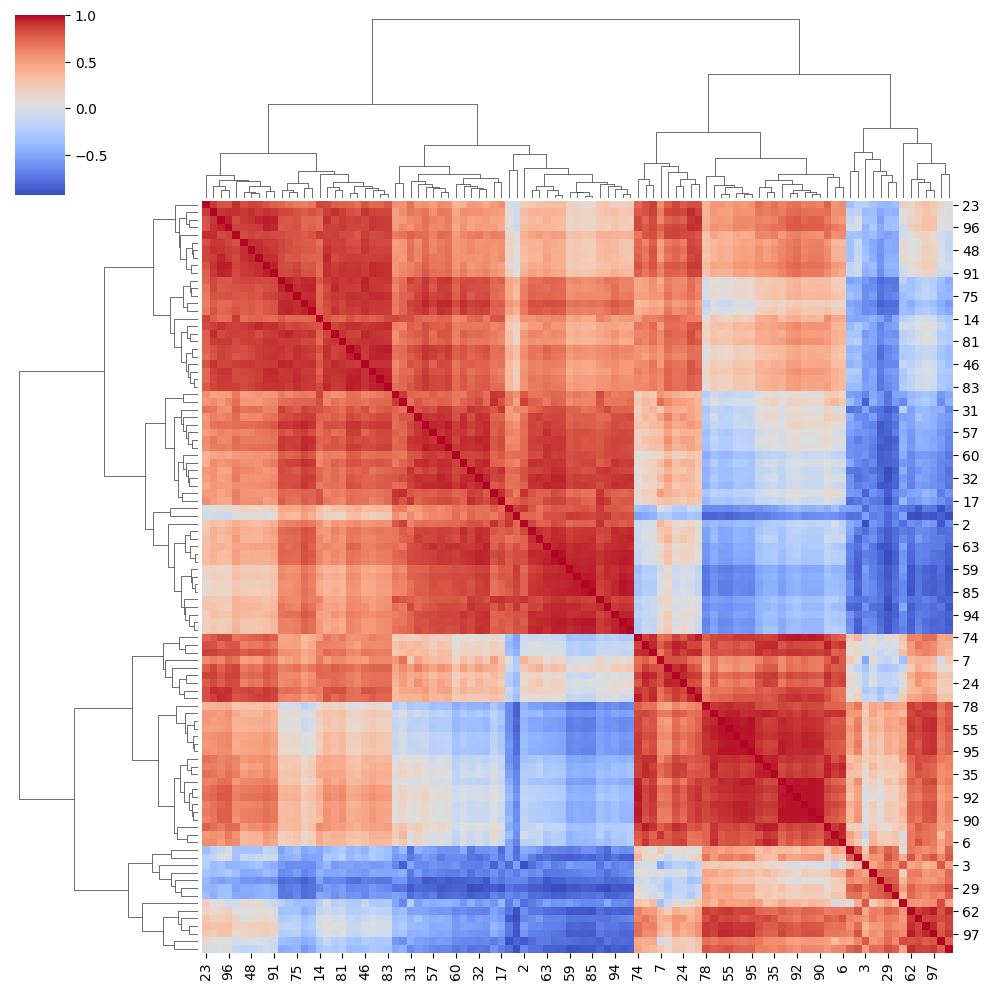

In [17]:
import torch, pyro
import matplotlib.pyplot as plt
import seaborn as sns                   

with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)
corr = vae._corr(Sigma_P_posterior).numpy()
sns.clustermap(corr, cmap="coolwarm", annot=False)


In [18]:
np.savetxt("./results/corr_matrix.csv", corr, delimiter=",")

In [19]:
corr_matrix = np.array(pd.read_csv("./results/corr_matrix.csv", header=None))
corr_matrix_2 = np.array(pd.read_csv("./results/corr_matrix_2.csv", header=None))


In [20]:
from scipy.stats import pearsonr

# Flatten the upper triangular parts of both matrices (excluding the diagonal)
triu_indices = np.triu_indices_from(corr_matrix, k=1)
corr_matrix_flat = corr_matrix[triu_indices]
corr_matrix_2_flat = corr_matrix_2[triu_indices]

# Compute Pearson correlation
pearson_corr, p_value = pearsonr(corr_matrix_flat, corr_matrix_2_flat)
print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {p_value:.3e}")

Pearson correlation: 0.035, p-value: 1.437e-02


In [21]:
# z = trace.nodes["z"]["value"]
# z0 = trace.nodes["z0"]["value"]

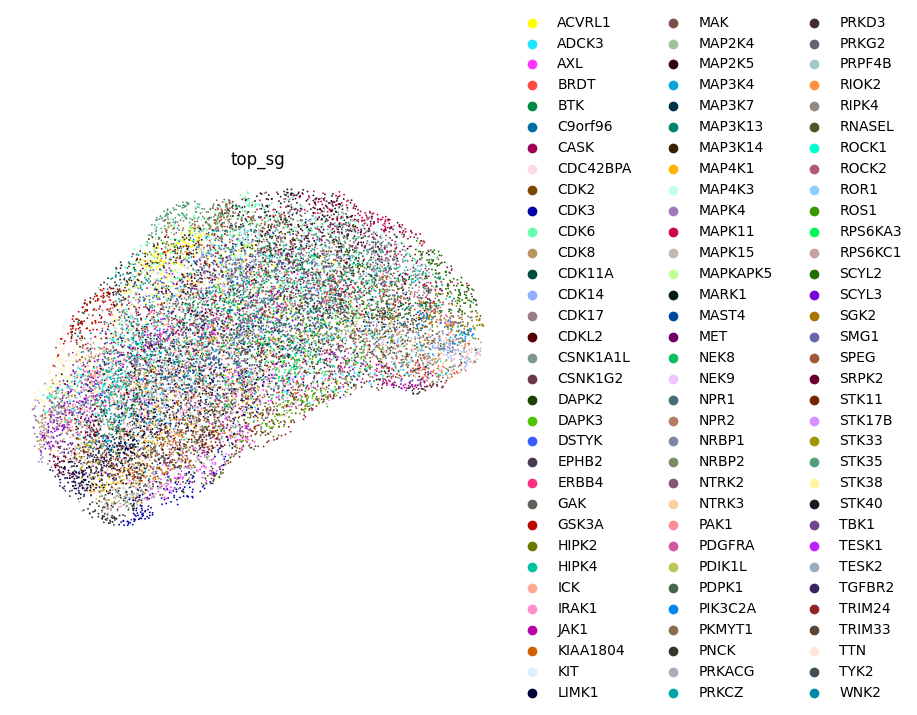

In [22]:
# z_data = data[data.obs.top_sg != 'NTC'].copy()
# z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, n_neighbors=15, use_rep='X')
sc.tl.umap(z_data)
sc.pl.umap(z_data, color=['top_sg'], frameon=False, show=True)

In [23]:
num_p = vae.perturbs
d = vae.latent_dim
Sigma_P_posterior = vae._corr(Sigma_P_posterior)
z_bar = torch.zeros(num_p, d)
counts = torch.zeros(num_p)
for p in range(num_p):
    mask = (P == p)
    if mask.any():
        z_bar[p] = z[mask].mean(0)
        counts[p] = mask.sum()

# (Optional) skip perturbations with very few cells
valid = counts > 2
Sigma_z = torch.corrcoef(z_bar[valid])          # (P_valid × P_valid)
Sigma_P_posterior = Sigma_P_posterior[valid][:, valid]              # align shapes

In [24]:
def flat_triu(M):
    idx = torch.triu_indices(M.size(0), M.size(1), offset=1)
    return M[idx[0], idx[1]]

rho_flat  = flat_triu(Sigma_P_posterior).numpy()
z_flat    = flat_triu(Sigma_z.detach()).numpy()

from scipy.stats import spearmanr, pearsonr
r_s, p_s = spearmanr(rho_flat, z_flat)
r_p, p_p = pearsonr(rho_flat, z_flat)

print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.1e})")
print(f" Pearson  r = {r_p:.3f}  (p = {p_p:.1e})")

Spearman ρ = 0.671  (p = 0.0e+00)
 Pearson  r = 0.526  (p = 0.0e+00)


In [25]:
sigma_w = vae.E_pert_sim(min_conf=0.2).detach().cpu().numpy()

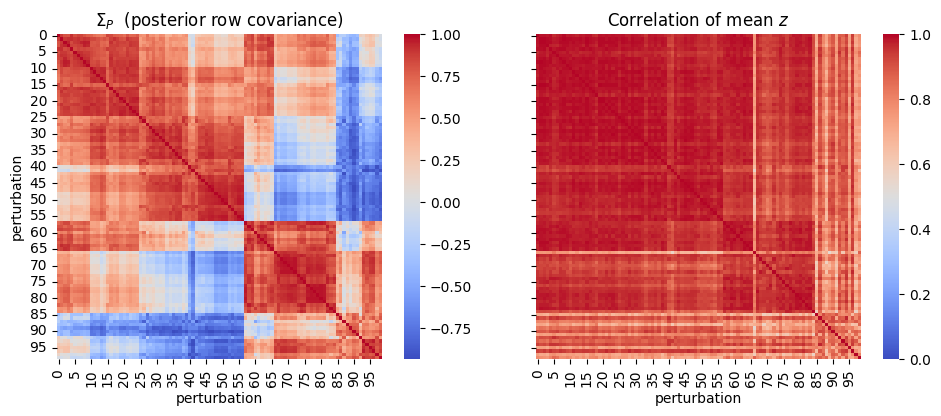

In [ ]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib import gridspec

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list


link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
order = leaves_list(link)              # permutation indices, shape (P,)

# ── 2.  apply the same permutation to both matrices ─────────────────
SigmaP_ord = Sigma_P_posterior[order][:, order]

# Sigma_z : correlation between perturbation-mean z’s  (P × P)
Sigmaz_ord = Sigma_z.detach().cpu().numpy()[order][:, order]

# Sigma w:
Sigmaw_ord = sigma_w[order][:, order]

# ── 3.  plot side-by-side heat-maps ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title(r"$\Sigma_P$  (posterior row covariance)")
axes[0].set_xlabel("perturbation"); axes[0].set_ylabel("perturbation")

sns.heatmap(Sigmaz_ord, cmap="coolwarm", square=True, ax=axes[1], vmin=0.3)
axes[1].set_title("Correlation of mean $z$")
axes[1].set_xlabel("perturbation")


plt.tight_layout()
plt.show()

In [27]:
n_classes = P.unique().shape[0]
centroids = torch.stack([z[P==k].mean(0) for k in range(n_classes)])
inter = centroids.var(0).sum()
intra = (z - centroids[P]).var(0).sum()
print("inter / intra variance :", inter.item() / intra.item())


inter / intra variance : 2.4044260592665094


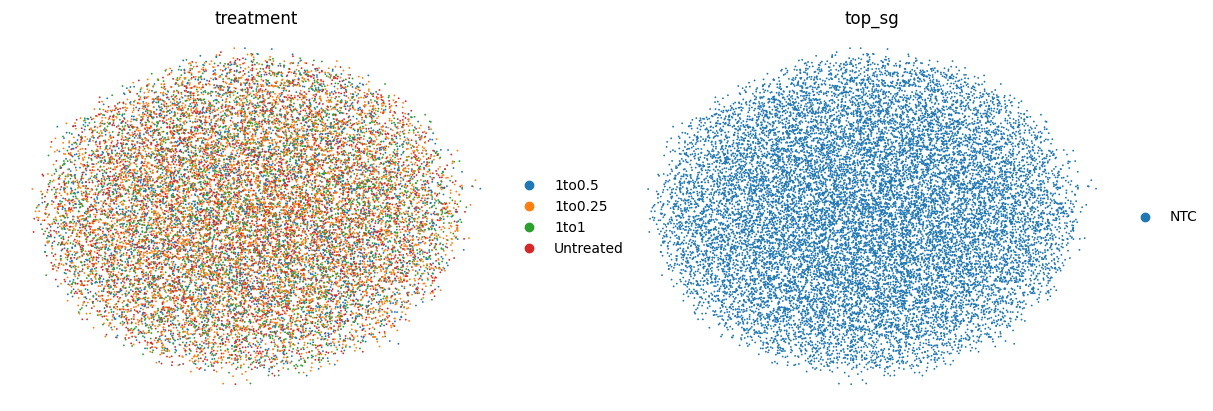

In [28]:
# z0_data = data.copy()
# z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='X', n_neighbors=15)
sc.tl.umap(z0_data)
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [29]:
pi = trace.nodes["pi"]['value']
pi

tensor([[0.3208, 0.5836, 0.2480,  ..., 0.2787, 0.3560, 0.4908],
        [0.4263, 0.2821, 0.2665,  ..., 0.3752, 0.3746, 0.3268],
        [0.4158, 0.3866, 0.3021,  ..., 0.4511, 0.3729, 0.5486],
        ...,
        [0.3055, 0.4236, 0.2462,  ..., 0.4224, 0.4606, 0.5461],
        [0.4286, 0.3698, 0.2309,  ..., 0.2535, 0.2703, 0.2585],
        [0.3185, 0.6673, 0.2608,  ..., 0.4113, 0.3969, 0.5415]],
       grad_fn=<ExpandBackward0>)

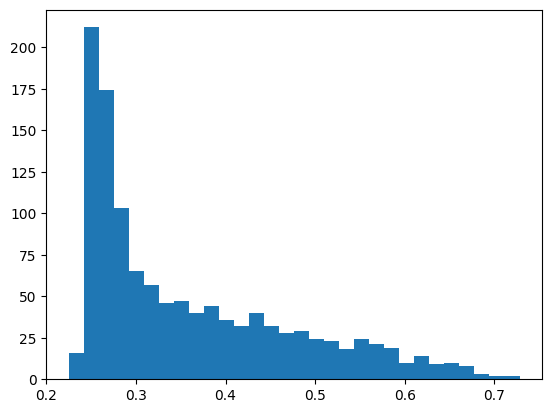

<Axes: >

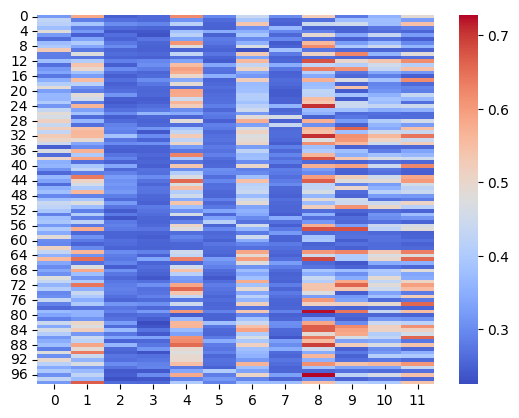

In [30]:
plt.hist(pi.detach().cpu().numpy().flatten(), bins=30)
plt.show()
sns.heatmap(pi.detach().cpu().numpy(), cmap="coolwarm")

In [31]:
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, metric='euclidean', random_state=0)
Z2 = reducer.fit_transform(z.detach().cpu().numpy())

/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [32]:
import numpy as np
centroids = np.zeros((vae.perturbs, z.shape[1]))
for a in range(vae.perturbs):
    centroids[a] = z.detach()[P == a].mean(0)
cent2 = reducer.transform(centroids)

In [33]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
C = vae._corr(Sigma_P_posterior).cpu().numpy()
D = 1.0 - C  # distance
Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
# groups = fcluster(Z_link, t=0.5, criterion='distance')  # tune t

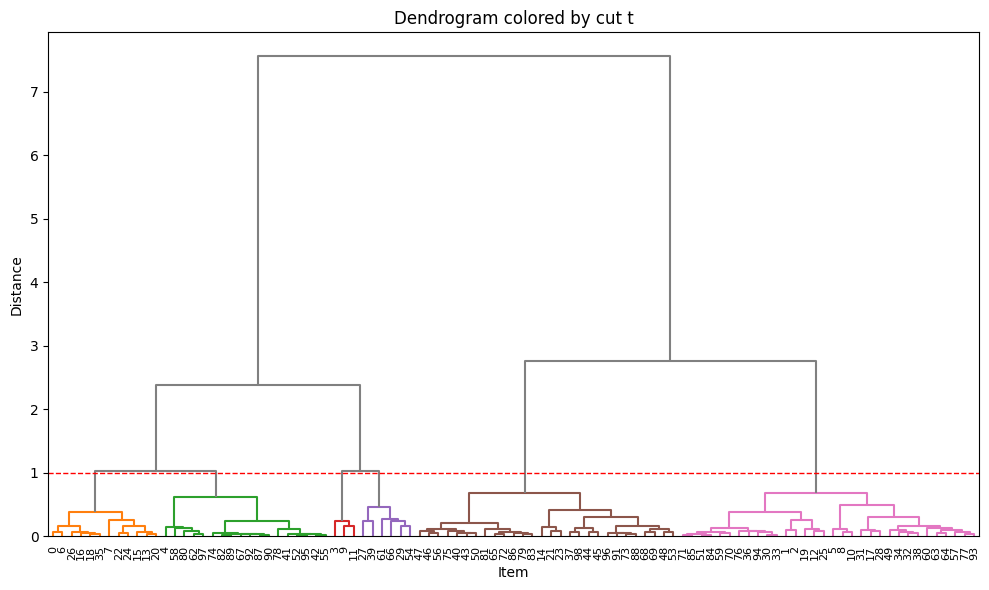

In [34]:
t = 1  # your cut in the same distance scale as Z_link

plt.figure(figsize=(10, 6))
dendrogram(
    Z_link,
    color_threshold=t,            # <-- color branches by your cut
    above_threshold_color="gray", # color for branches above the cut
    labels=np.arange(len(C)),     # optional
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
plt.title("Dendrogram colored by cut t")
plt.xlabel("Item")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Cluster labels at the same cut
groups = fcluster(Z_link, t=t, criterion='distance')

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib as mpl


def _discrete_cmap(n, base_cmap='tab20'):
    """
    Make an n-bin discrete ListedColormap from a continuous or qualitative base cmap.
    For large n (e.g., 100), interpolating a continuous cmap (turbo, viridis, gist_ncar)
    actually yields *more* distinct colors than repeating a short qualitative palette.
    """
    base = plt.cm.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, n))
    return ListedColormap(color_list)


def _scanpy_categorical_palette(n, prefer='default', fallback_cmap='gist_ncar'):
    """
    Return a list of n distinct colors using Scanpy's categorical palettes.
    Parameters
    ----------
    n : int
        Number of categories needed.
    prefer : {'default','zeileis','vega','scanpy','any'}
        Preference heuristic; 'default' tries Scanpy's default_* palettes first.
    fallback_cmap : str
        Matplotlib cmap name to fall back to if scanpy unavailable.
    """
    try:
        import scanpy as sc
    except ImportError:
        # fallback: discrete colormap from matplotlib
        return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)

    pals = []
    # Build candidate palettes in preference order
    if prefer in ('default', 'any'):
        pals.extend([
            sc.pl.palettes.default_20,
            getattr(sc.pl.palettes, 'default_28', []),
            sc.pl.palettes.default_102,   # length 102
        ])
    if prefer in ('zeileis', 'any'):
        # Zeileis palettes are good for many categories
        pals.extend([
            sc.pl.palettes.zeileis_26,
            sc.pl.palettes.zeileis_102,   # length 102
        ])
    if prefer in ('vega', 'scanpy', 'any'):
        # Additional widely used palettes
        pals.extend([
            sc.pl.palettes.vega_20_scanpy,
            sc.pl.palettes.vega_20,       # original vega
        ])

    # deduplicate while preserving order
    seen = set()
    uniq_pals = []
    for pal in pals:
        if pal is None:
            continue
        # convert to tuple so hashable
        tpl = tuple(pal)
        if tpl in seen:
            continue
        seen.add(tpl)
        uniq_pals.append(list(pal))

    # choose the *smallest* palette that still covers n
    chosen = None
    for pal in uniq_pals:
        if len(pal) >= n:
            chosen = pal[:n]
            break

    if chosen is None:
        # no palette long enough; take the longest and extend by cycling
        longest = max(uniq_pals, key=len) if uniq_pals else []
        if not longest:  # still empty? fallback
            return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)
        reps = int(np.ceil(n / len(longest)))
        chosen = (longest * reps)[:n]

    return chosen


def plot_umap_cells_by_cluster_and_pert(
    Z2, P, cent2, groups,
    *,
    cluster_base_cmap=None,
    pert_base_cmap='gist_ncar',
    use_scanpy_palette_for_pert=True,
    use_scanpy_palette_for_groups=False,
    scanpy_palette_prefer='default',
    cell_size=5,
    alpha_cells=0.6,
    centroid_size=80,
    annotate_centroids=False,
    max_cluster_legend=25,
    fig_kw=None,
):
    Z2 = np.asarray(Z2)
    P = np.asarray(P, dtype=int)
    cent2 = np.asarray(cent2)
    groups = np.asarray(groups)

    n_cells = Z2.shape[0]
    n_pert = cent2.shape[0] if cent2 is not None else P.max() + 1

    # ---- cluster mapping ----
    grp_labels, grp_codes = np.unique(groups, return_inverse=True)  # grp_codes: (n_pert,)
    G = len(grp_labels)
    cell_grp = grp_codes[P]  # cluster id per cell

    # choose cluster cmap
    if use_scanpy_palette_for_groups:
        cluster_colors = _scanpy_categorical_palette(G, prefer=scanpy_palette_prefer)
        cluster_cmap = ListedColormap(cluster_colors)
    else:
        if cluster_base_cmap is None:
            if G <= 10:
                cluster_base_cmap = 'tab10'
            elif G <= 20:
                cluster_base_cmap = 'tab20'
            else:
                cluster_base_cmap = 'hsv'
        cluster_cmap = _discrete_cmap(G, base_cmap=cluster_base_cmap)
        cluster_colors = cluster_cmap(np.arange(G))

    # per-perturbation cmap
    if use_scanpy_palette_for_pert:
        pert_colors = _scanpy_categorical_palette(n_pert, prefer=scanpy_palette_prefer,
                                                  fallback_cmap=pert_base_cmap)
        pert_cmap = ListedColormap(pert_colors)
    else:
        pert_cmap = _discrete_cmap(n_pert, base_cmap=pert_base_cmap)

    # ---- figure ----
    if fig_kw is None:
        fig_kw = {}
    fig, axes = plt.subplots(
        1, 2,
        figsize=fig_kw.get('figsize', (12, 5)),
        sharex=True, sharey=True,
        gridspec_kw=fig_kw.get('gridspec_kw', None),
        constrained_layout=fig_kw.get('constrained_layout', False)
    )

    axc, axp = axes

    # ------------------------------------------------------------------
    # Panel 1: Cells colored by cluster
    # ------------------------------------------------------------------
    axc.scatter(
        Z2[:, 0], Z2[:, 1],
        c=cell_grp,
        cmap=cluster_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    axc.set_title("z space, Cells colored by perturbation groups", fontsize=10)

    # Legend (clusters)
    if G <= max_cluster_legend:
        if use_scanpy_palette_for_groups:
            cluster_colors_arr = np.array(cluster_colors)
        else:
            cluster_colors_arr = cluster_cmap(np.arange(G))
        handles = [
            mpatches.Patch(color=cluster_colors_arr[i], label=f"group {grp_labels[i]}")
            for i in range(G)
        ]
        axc.legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            title='Perturbation groups'
        )

    # ------------------------------------------------------------------
    # Panel 2: Cells colored by individual perturbation (Scanpy colors)
    # ------------------------------------------------------------------
    axp.scatter(
        Z2[:, 0], Z2[:, 1],
        c=P,
        cmap=pert_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    if annotate_centroids:
        for a, (x_, y_) in enumerate(cent2):
            axp.text(x_, y_, str(a), ha='center', va='center', fontsize=4, zorder=4)

    axp.set_title("z space, Cells colored by perturbation", fontsize=10)

    # Colorbar for perturbations (compact; index scale 0..n_pert-1)
    stride = max(1, n_pert // 20)  # show at most ~20 ticks
    ticks = np.arange(0, n_pert, stride)
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pert-1), cmap=pert_cmap),
        ax=axp,
        fraction=0.046,
        pad=0.04,
    )
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticks.astype(str))
    cbar.set_label("Perturbation ID")

    # ------------------------------------------------------------------
    # Finishing touches
    # ------------------------------------------------------------------
    for ax in axes:
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    return fig, axes


/var/tmp/ipykernel_1547429/2393065932.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap(base_cmap)


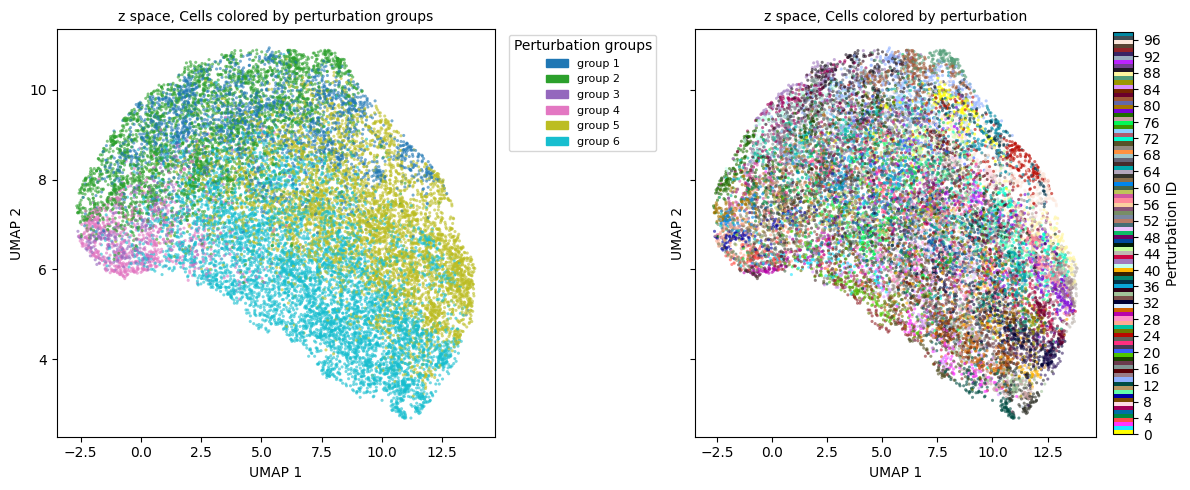

In [36]:
fig, axes = plot_umap_cells_by_cluster_and_pert(
    Z2=Z2,
    P=P,
    cent2=cent2,
    groups=groups,
    pert_base_cmap='nipy_spectral',   # high-contrast for many categories
    annotate_centroids=False,     # set True to label perturbations at centroids
)
plt.show()

In [37]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt
import numpy as np

def cluster_and_plot(corr_matrix, t=1.0, title="Dendrogram"):
    """
    Performs hierarchical clustering on a correlation matrix and plots dendrogram.

    Returns:
        groups: np.ndarray of cluster labels
    """
    D = 1.0 - corr_matrix
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    groups = fcluster(Z_link, t=t, criterion='distance')

    plt.figure(figsize=(10, 6))
    dendrogram(
        Z_link,
        color_threshold=t,
        above_threshold_color="gray",
        labels=np.arange(len(corr_matrix)),
        leaf_rotation=90,
        leaf_font_size=8,
    )
    plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
    plt.title(title + f" (cutoff t={t})")
    plt.xlabel("Item")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

    return groups


In [39]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(groups_1, groups_2)
nmi = normalized_mutual_info_score(groups_1, groups_2)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Adjusted Rand Index (ARI): 0.0263
Normalized Mutual Information (NMI): 0.1656


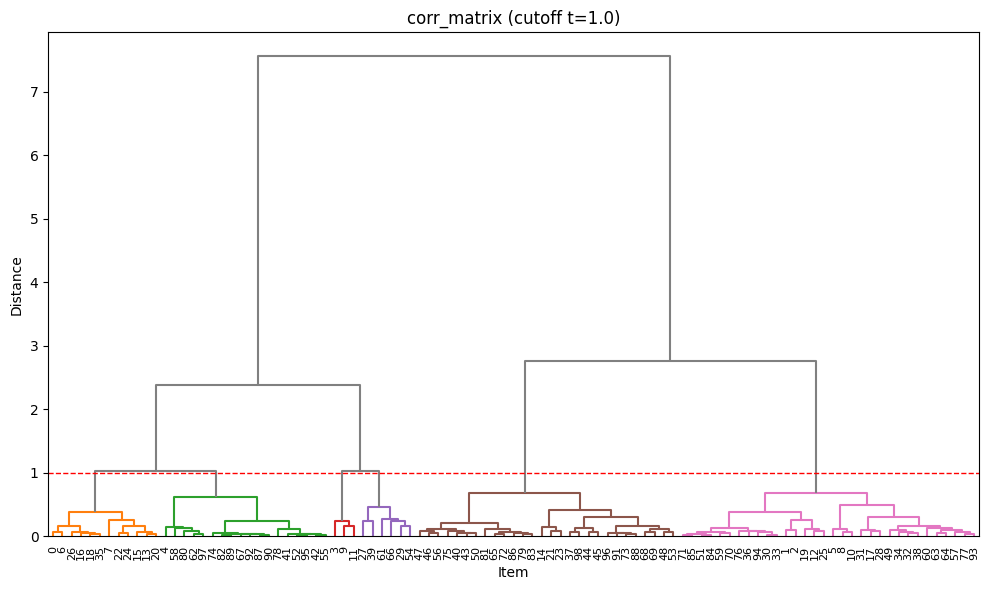

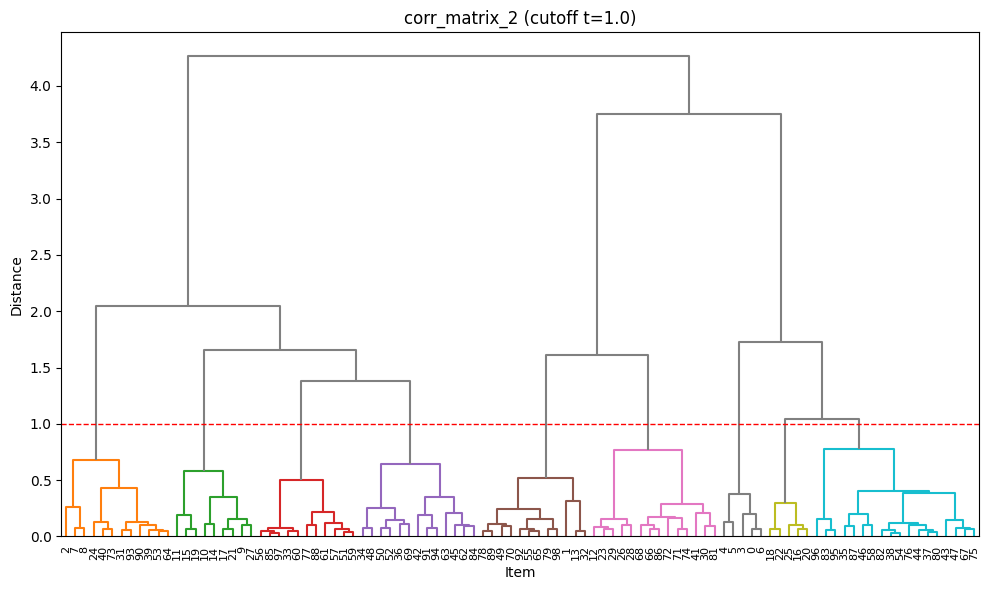

In [38]:
import pandas as pd

# Load the two correlation matrices
corr_matrix = np.array(pd.read_csv("./results/corr_matrix.csv", header=None))
corr_matrix_2 = np.array(pd.read_csv("./results/corr_matrix_2.csv", header=None))

# Cluster and visualize both
t = 1.0
groups_1 = cluster_and_plot(corr_matrix, t=t, title="corr_matrix")
groups_2 = cluster_and_plot(corr_matrix_2, t=t, title="corr_matrix_2")


# Check W consistency

In [13]:
def _initialize_vaes(dataset, gene_module_dict, n_models=5):
    vaes = []
    for _ in range(n_models):
        # Initialize a new VAE for each model
        input_dim = data.shape[-1] 
        latent_dim = len(gene_module_dict.keys())
        vae = VAE(input_dim, latent_dim, 
                  len(np.unique(dataset.P_indices)),
                  len(np.unique(dataset.C_indices)),
                  100, module_dict=gene_module_dict,
                  center_coeff_init=1e-2)
        vae = vae.to(vae.device)
        vaes.append(vae)
    return vaes

In [14]:
models = _initialize_vaes(dataset, gene_module_dict, n_models=5)

In [15]:
import tqdm

In [16]:
for i in tqdm.tqdm(range(len(models))):
    trainer = VAETrainer(
        models[i],
        dataloader,
        lr=1e-3,
        num_epochs=20,
        init_coeff=models[i].center_coeff_init,                 
        final_coeff=1e-1,                 
        ramp_steps=10000,
        tau_init=1.0,
        tau_end=0.1,
        tau_anneal_steps=10000,
        verbose=False,
        seed=i + 42
    )
    trainer.fit()

  0%|                                                                                                                                 | 0/5 [00:00<?, ?it/s]

Training VAE on cuda …


 20%|████████████████████████                                                                                                | 1/5 [05:20<21:23, 320.85s/it]

Training VAE on cuda …


 40%|████████████████████████████████████████████████                                                                        | 2/5 [10:43<16:05, 321.93s/it]

...

 60%|████████████████████████████████████████████████████████████████████████                                                | 3/5 [16:02<10:41, 320.71s/it]

Training VAE on cuda …


 80%|████████████████████████████████████████████████████████████████████████████████████████████████                        | 4/5 [21:21<05:19, 319.86s/it]

Training VAE on cuda …


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [26:40<00:00, 320.15s/it]


In [17]:
from utils import *

In [18]:
def _model_trace(model, dataset):
    model.eval()
    model.device = torch.device('cpu')
    model = model.to(model.device)
    print(model.device)

    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):        # list() -> safe while mutating
        param_store[name] = value.to(torch.device('cpu'))             # keep grad history

    X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

    trace = poutine.trace(model.guide).get_trace(X, P, C)
    trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X, P, C)
    return trace, trace_model

In [19]:
Ws, Pis = [], []             # graph-level statistics
Zs, Z0s, Rhos = [], [], []    # optional latent diagnostics

for run_idx, vae in enumerate(tqdm.tqdm(models, desc="collect posteriors")):

    # --------  move model + params to CPU and eval mode  ----------
    vae.eval()
    vae.to("cpu")
    pyro.get_param_store()         # keep gradients intact if needed

    q_pi = pyro.param("q_pi").detach().clone()        # shape (d,)
    print(torch.mean(q_pi))
    print(torch.max(q_pi))
    Pis.append(q_pi)
    S_map = get_bipartite_graph(mode="weighted", threshold=0.5)
    Ws.append(S_map)

    # --------  draw one trace if you want latent snapshots  -------
    X = torch.tensor(dataset.X)
    P = torch.tensor(dataset.P_indices)
    C = torch.tensor(dataset.C_indices)

    trace = pyro.poutine.trace(vae.guide).get_trace(X, P, C)

    Zs.append(trace.nodes["z"]["value"].detach().cpu())
    Z0s.append(trace.nodes["z0"]["value"].detach().cpu())
    Rhos.append(trace.nodes["rho"]["value"].detach().cpu())


collect posteriors:   0%|                                                                                                             | 0/5 [00:00<?, ?it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  20%|████████████████████▏                                                                                | 1/5 [00:00<00:01,  2.20it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  40%|████████████████████████████████████████▍                                                            | 2/5 [00:00<00:01,  2.17it/s]

...

collect posteriors:  60%|████████████████████████████████████████████████████████████▌                                        | 3/5 [00:01<00:00,  2.30it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors:  80%|████████████████████████████████████████████████████████████████████████████████▊                    | 4/5 [00:01<00:00,  2.33it/s]

tensor(0.1250, device='cuda:0')
tensor(0.1298, device='cuda:0')


collect posteriors: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.32it/s]


In [22]:
from __future__ import annotations
import itertools, math
import torch, pyro, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
from typing import Sequence, Union

def _qpi_to_numpy(model) -> np.ndarray:
    """
    Fetch q_pi from a trained model and return (P,d) numpy array.
    Assumes model already uses canonicalise_columns_by_module().
    """
    q = pyro.param("q_pi", model.device).detach().cpu().numpy()
    return q


def compare_and_plot_pi(models   : Sequence[torch.nn.Module],
                        thresh   : float = 0.5,
                        cmap     : str = "Blues",
                        figsize  : tuple[int, int] | None = None):

    # ----------  collect q_pi  ------------------------------------
    Qs = [_qpi_to_numpy(m) for m in models]        # list of (P,d)
    R  = len(Qs)
    flat_Q = [q.flatten() for q in Qs]             # make 1D for corr

    # ----------  pairwise Pearson matrix --------------------------
    Pcorr = np.ones((R, R))
    for (i, q_i), (j, q_j) in itertools.combinations(enumerate(flat_Q), 2):
        corr = np.corrcoef(q_i, q_j)[0, 1]
        Pcorr[i, j] = Pcorr[j, i] = corr

    # ----------  prepare average & binary graph -------------------
    Q_mean  = np.stack(Qs).mean(0)                 # (P,d)
    Q_bin   = (Q_mean >= thresh).astype(int)       # 0/1 graph

    # ----------  plotting -----------------------------------------
    if figsize is None:
        figsize = (4*R, 4 + 1.5)       # heat-map strip + two little panels
    fig = plt.figure(figsize=figsize)

    # A) correlation heat-map
    ax0 = plt.subplot2grid((1, R+1), (0, 0), colspan=R)
    sns.heatmap(Pcorr, vmin=0, vmax=1, cmap="viridis",
                annot=True, fmt=".2f", square=True, ax=ax0,
                cbar_kws={"label": "Pearson r"})
    ax0.set_title("q_pi consistency across runs")
    ax0.set_xlabel("run"); ax0.set_ylabel("run")

    # B) average probability matrix
    ax1 = plt.subplot2grid((1, R+1), (0, R))
    sns.heatmap(Q_mean, cmap=cmap, square=False,
                cbar=True, ax=ax1)
    ax1.set_title("mean q_pi")
    ax1.set_xlabel("latent dim"); ax1.set_ylabel("perturbation")

    # C) binary bipartite graph (thresholded)
    fig2, ax2 = plt.subplots(figsize=(3, 4))
    sns.heatmap(Q_bin, cmap="Greys", cbar=False, ax=ax2)
    ax2.set_title(f"bipartite graph  (≥{thresh})")
    ax2.set_xlabel("latent dim"); ax2.set_ylabel("perturbation")
    plt.tight_layout()
    plt.show(block=False)

    return Pcorr, Q_mean, Q_bin

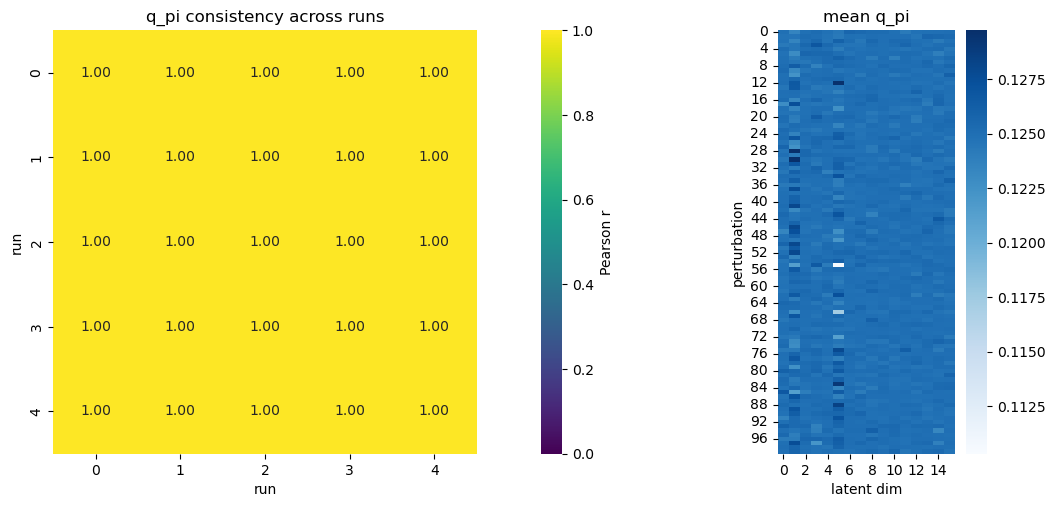

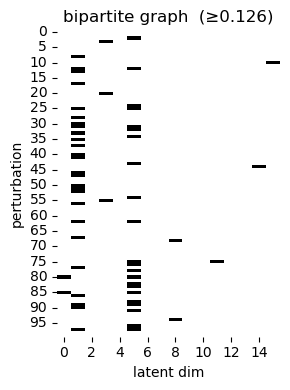

In [26]:
Pcorr, Q_mean, Q_bin = compare_and_plot_pi(models, thresh=0.126)

In [98]:
from utils import *

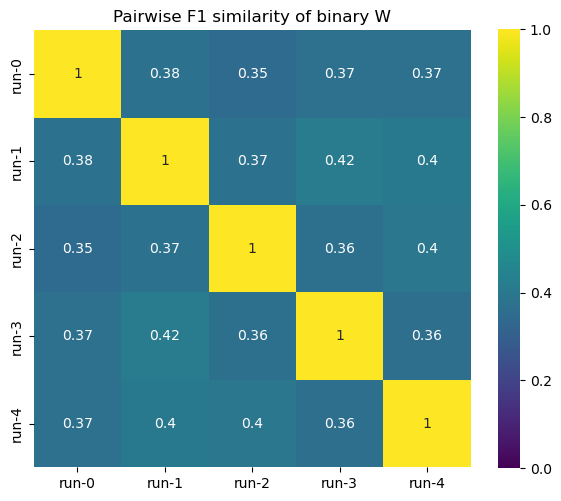

Mean f1 = 0.378 ± 0.020


In [ ]:
compare_W_runs_binary(, align=False)

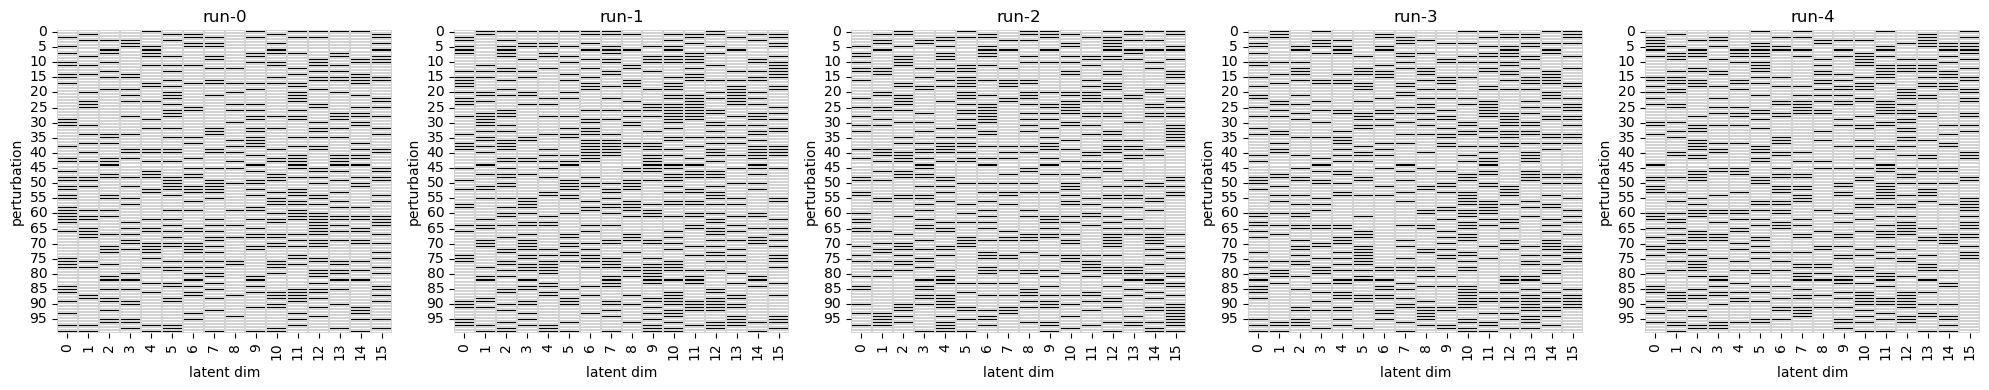

In [100]:
plot_binary_Ws(Ws)